<a href="https://colab.research.google.com/github/KSKAUSHIKRAM/Human-Activity-Recognition-from-Sensor-Data/blob/main/Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
def load_X(path, is_train=True):
    prefix = 'train' if is_train else 'test'

    files = [
        path + f'{prefix}/Inertial Signals/body_acc_x_{prefix}.txt',
        path + f'{prefix}/Inertial Signals/body_acc_y_{prefix}.txt',
        path + f'{prefix}/Inertial Signals/body_acc_z_{prefix}.txt',
        path + f'{prefix}/Inertial Signals/body_gyro_x_{prefix}.txt',
        path + f'{prefix}/Inertial Signals/body_gyro_y_{prefix}.txt',
        path + f'{prefix}/Inertial Signals/body_gyro_z_{prefix}.txt',
        path + f'{prefix}/Inertial Signals/total_acc_x_{prefix}.txt',
        path + f'{prefix}/Inertial Signals/total_acc_y_{prefix}.txt',
        path + f'{prefix}/Inertial Signals/total_acc_z_{prefix}.txt'
    ]

    data = [np.loadtxt(f) for f in files]
    return np.transpose(data, (1, 2, 0))


base_path = '/content/drive/MyDrive/Assigndataset/'

X_train = load_X(base_path, True)
X_test = load_X(base_path, False)

y_train = np.loadtxt(base_path + 'train/y_train.txt') - 1
y_test = np.loadtxt(base_path + 'test/y_test.txt') - 1

In [4]:
mean = X_train.mean(axis=(0,1))   # shape (9,)
std = X_train.std(axis=(0,1))     # shape (9,)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [5]:
import numpy as np

unique, counts = np.unique(y_train, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

Class 0.0: 1226 samples
Class 1.0: 1073 samples
Class 2.0: 986 samples
Class 3.0: 1286 samples
Class 4.0: 1374 samples
Class 5.0: 1407 samples


In [6]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.9994562262098967), 1: np.float64(1.1419695557626592), 2: np.float64(1.2427315753887762), 3: np.float64(0.9528252980819077), 4: np.float64(0.8918000970402717), 5: np.float64(0.8708836768538261)}


Vanilla lstm

In [7]:
def build_model_A():
    model = Sequential([
        LSTM(128, input_shape=(128, 9)),
        Dropout(0.3),
        Dense(6, activation='softmax')
    ])
    return model



STACKED LSTM

In [8]:
from tensorflow.keras.layers import LayerNormalization
def build_model_B():
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(128, 9)),
        LayerNormalization(),
        LSTM(64),
        Dropout(0.4),
        Dense(6, activation='softmax')
    ])
    return model

CNN+LSTM


In [28]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, BatchNormalization, Input
def build_model_C():
    # Explicitly define an Input layer
    inputs = Input(shape=(128, 9))

    x = Conv1D(64, 3, activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling1D()(x)

    x = Conv1D(128, 3, activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D()(x)

    x = Conv1D(128, 3, activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D()(x)

    x = LSTM(128)(x)
    outputs = Dense(6, activation='softmax')(x)

    model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
    return model

In [10]:
def compile_model(model):
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=1e-3,
        decay_steps=50
    )

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [11]:
import time
def train_model(model, X_train, y_train, class_weights):
    start = time.time()

    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=64,
        validation_split=0.2,
        class_weight=class_weights,
        verbose=1
    )

    end = time.time()
    time_per_epoch = (end - start) / 50

    return history, time_per_epoch

In [12]:
from sklearn.metrics import f1_score
def evaluate_model(model, X_test, y_test):
    y_pred = np.argmax(model.predict(X_test), axis=1)

    acc = np.mean(y_pred == y_test)
    f1 = f1_score(y_test, y_pred, average='macro')

    print("Accuracy:", acc)
    print("Macro F1:", f1)
    print(classification_report(y_test, y_pred))

    return y_pred

In [13]:
import seaborn as sns
def plot_confusion(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [29]:
# Build models
model_A = compile_model(build_model_A())
model_B = compile_model(build_model_B())
model_C = compile_model(build_model_C())

# Train
history_A, time_A = train_model(model_A, X_train, y_train, class_weights)
history_B, time_B = train_model(model_B, X_train, y_train, class_weights)
history_C, time_C = train_model(model_C, X_train, y_train, class_weights)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6276 - loss: 1.0124 - val_accuracy: 0.6995 - val_loss: 0.8577
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6864 - loss: 0.8503 - val_accuracy: 0.6995 - val_loss: 0.8577
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6902 - loss: 0.8512 - val_accuracy: 0.6995 - val_loss: 0.8577
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6978 - loss: 0.8496 - val_accuracy: 0.6995 - val_loss: 0.8577
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6926 - loss: 0.8478 - val_accuracy: 0.6995 - val_loss: 0.8577
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6943 - loss: 0.8498 - val_accuracy: 0.6995 - val_loss: 0.8577
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6890 - loss: 0.8494 - val_accuracy: 0.6995 - val_loss: 0.8577
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6926 - loss: 0.8494 - val_accuracy: 0.6995 - v

In [15]:
import pickle
pickle.dump(history_A.history, open('history_A.pkl', 'wb'))
pickle.dump(history_B.history, open('history_B.pkl', 'wb'))
pickle.dump(history_C.history, open('history_C.pkl', 'wb'))

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Accuracy: 0.6532066508313539
Macro F1: 0.631160581323377
              precision    recall  f1-score   support

         0.0       0.51      0.26      0.34       496
         1.0       0.48      0.61      0.54       471
         2.0       0.59      0.53      0.56       420
         3.0       0.60      0.94      0.73       491
         4.0       0.71      0.58      0.64       532
         5.0       0.99      0.97      0.98       537

    accuracy                           0.65      2947
   macro avg       0.65      0.65      0.63      2947
weighted avg       0.66      0.65      0.64      2947

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Accuracy: 0.8147268408551069
Macro F1: 0.8100622095190543
              precision    recall  f1-score   support

         0.0       0.77      0.74      0.75       496
         1.0       0.75      0.69      0.72       471
         2.0       0.77      0.81      0.79       420
         3.0       0.76      0.83      0.79    

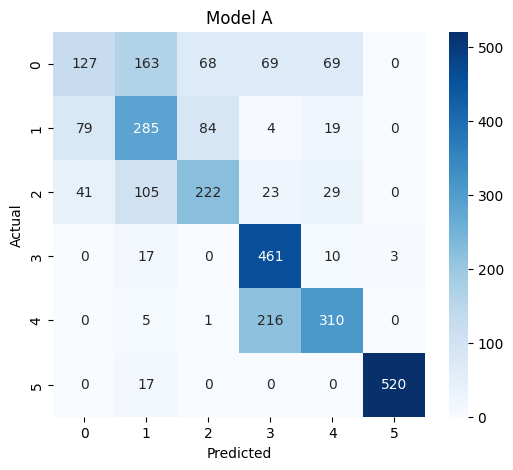

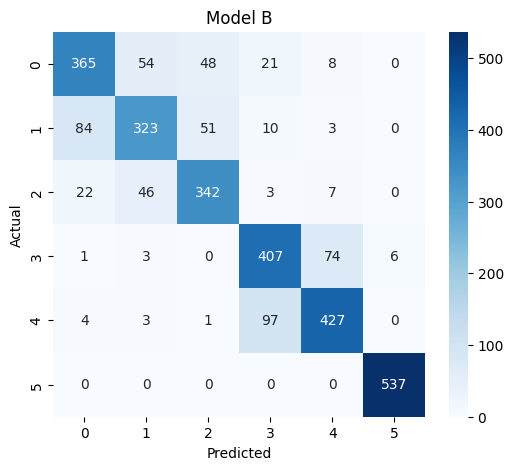

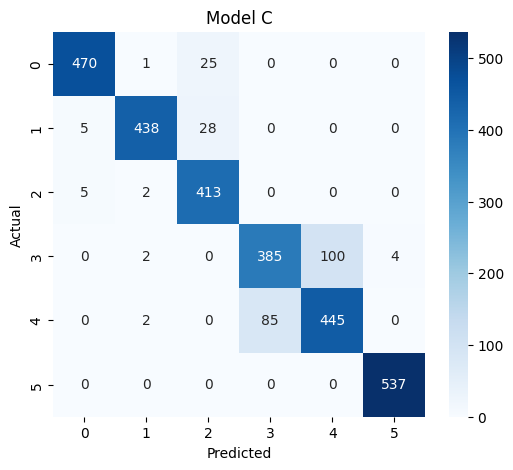

In [16]:
y_pred_A = evaluate_model(model_A, X_test, y_test)
y_pred_B = evaluate_model(model_B, X_test, y_test)
y_pred_C = evaluate_model(model_C, X_test, y_test)

plot_confusion(y_test, y_pred_A, "Model A")
plot_confusion(y_test, y_pred_B, "Model B")
plot_confusion(y_test, y_pred_C, "Model C")

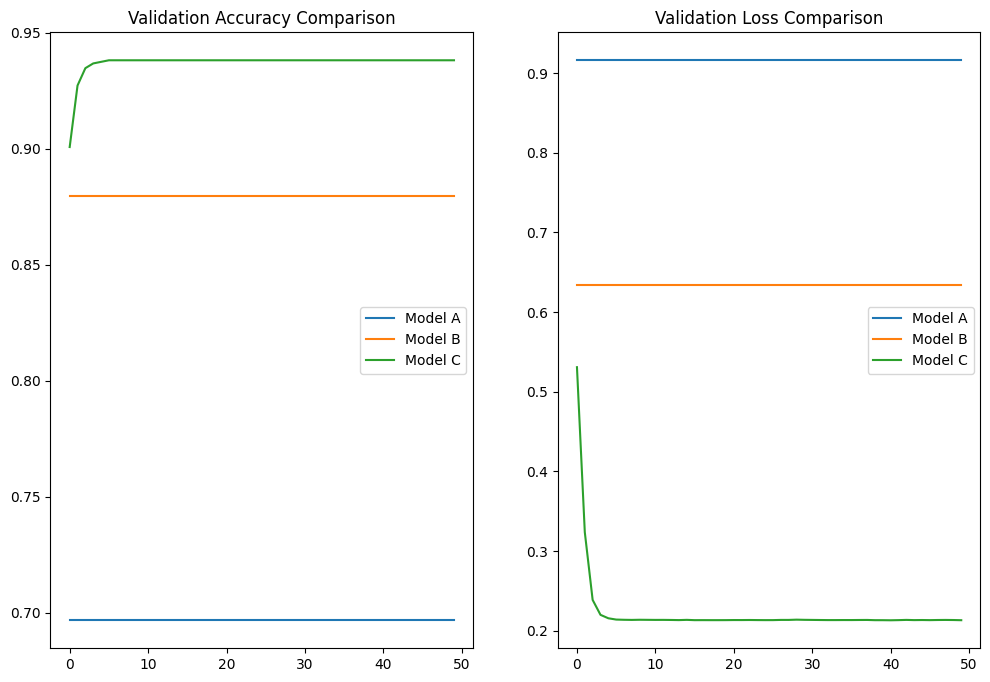

In [17]:
plt.figure(figsize=(12,8))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_A.history['val_accuracy'], label='Model A')
plt.plot(history_B.history['val_accuracy'], label='Model B')
plt.plot(history_C.history['val_accuracy'], label='Model C')
plt.title("Validation Accuracy Comparison")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_A.history['val_loss'], label='Model A')
plt.plot(history_B.history['val_loss'], label='Model B')
plt.plot(history_C.history['val_loss'], label='Model C')
plt.title("Validation Loss Comparison")
plt.legend()

plt.show()

In [18]:
import time
def measure_latency(model, X_test):
    start = time.time()
    model.predict(X_test[:1])
    end = time.time()
    return (end - start)

print("Latency A:", measure_latency(model_A, X_test))
print("Latency B:", measure_latency(model_B, X_test))
print("Latency C:", measure_latency(model_C, X_test))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Latency A: 0.10047101974487305
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Latency B: 0.07274603843688965
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Latency C: 0.15364813804626465


In [26]:
def gradcam_1d(model, sample):
    sample = np.expand_dims(sample, axis=0)

    # Explicitly call the model once to ensure it's built and its input/output tensors are materialized
    _ = model(sample)

    # Find last Conv1D layer
    last_conv_layer = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv1D):
            last_conv_layer = layer

    if last_conv_layer is None:
        raise ValueError("Model does not contain any Conv1D layer required for Grad-CAM.")

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(sample)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    # Importance weights
    weights = tf.reduce_mean(grads, axis=1)

    cam = tf.reduce_sum(tf.multiply(weights[:, tf.newaxis, :], conv_outputs), axis=-1)
    cam = tf.nn.relu(cam)

    cam = cam.numpy()[0]

    # Normalize
    cam = cam / np.max(cam)

    return cam

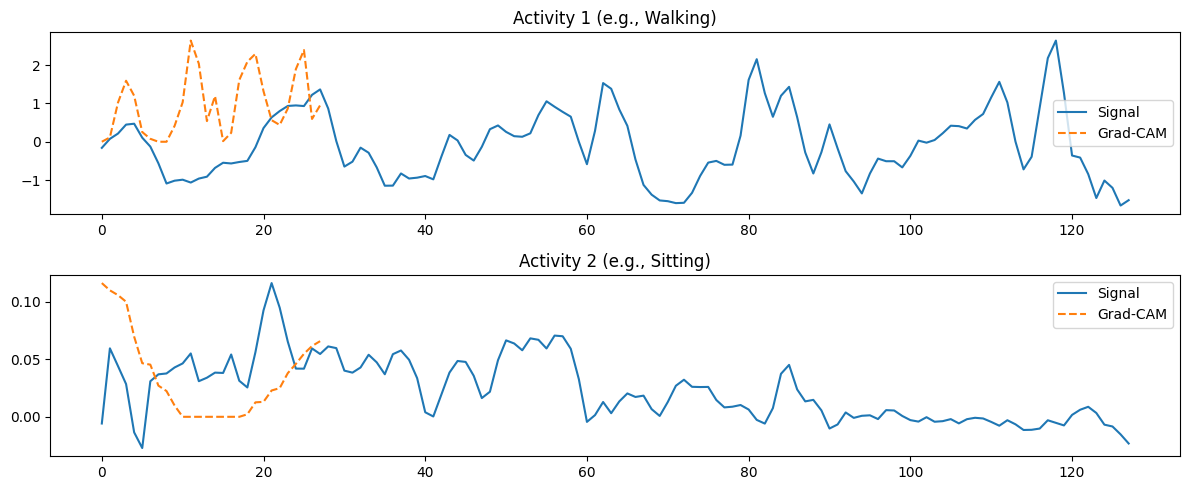

In [31]:
# Find indices of two different classes
idx1 = np.where(y_test == 0)[0][0]   # e.g., Walking
idx2 = np.where(y_test == 3)[0][0]   # e.g., Sitting

sample1 = X_test[idx1]
sample2 = X_test[idx2]

cam1 = gradcam_1d(model_C, sample1)
cam2 = gradcam_1d(model_C, sample2)

plt.figure(figsize=(12,5))

# Sample 1
plt.subplot(2,1,1)
plt.plot(sample1[:,0], label="Signal")
plt.plot(cam1 * np.max(sample1[:,0]), '--', label="Grad-CAM")
plt.title("Activity 1 (e.g., Walking)")
plt.legend()

# Sample 2
plt.subplot(2,1,2)
plt.plot(sample2[:,0], label="Signal")
plt.plot(cam2 * np.max(sample2[:,0]), '--', label="Grad-CAM")
plt.title("Activity 2 (e.g., Sitting)")
plt.legend()

plt.tight_layout()
plt.show()

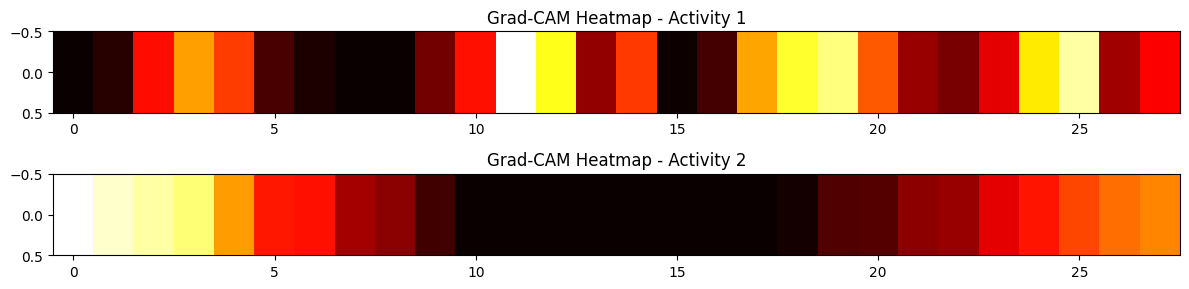

In [32]:
plt.figure(figsize=(12,3))

plt.subplot(2,1,1)
plt.imshow(cam1.reshape(1,-1), cmap='hot', aspect='auto')
plt.title("Grad-CAM Heatmap - Activity 1")

plt.subplot(2,1,2)
plt.imshow(cam2.reshape(1,-1), cmap='hot', aspect='auto')
plt.title("Grad-CAM Heatmap - Activity 2")

plt.tight_layout()
plt.show()